# Group 1 ML Final Project - Team Members: Sami Shikhare, Navya Bhatia, Joane Sarfati, Mrudhvika Srineni, Mya Stewart


In [2]:
#Load the Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor
import os

#os.getcwd()
os.chdir("/Users/mya/Downloads/scu/msba/isba2403")

red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')


## Exploratory Data Analysis

In [4]:
# check shape of dataset and first few rows
print("Red shape:", red.shape)
print("White shape:", white.shape)

print(red.head())
print(white.head())

Red shape: (1599, 12)
White shape: (4898, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        

In [5]:
# check for missing data
red.isna().any()
white.isna().any()


fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality                 False
dtype: bool

In [6]:
red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
white.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Results: No missing data!!

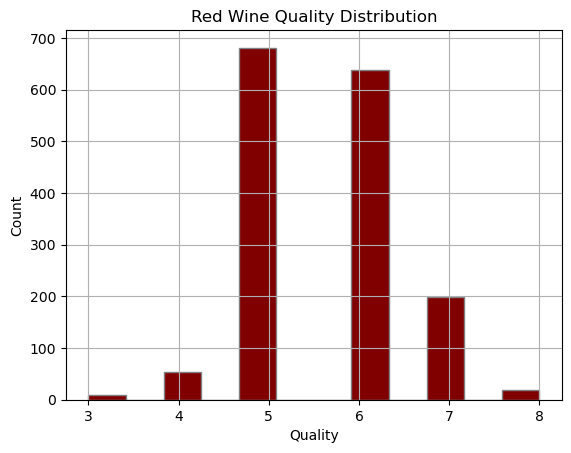

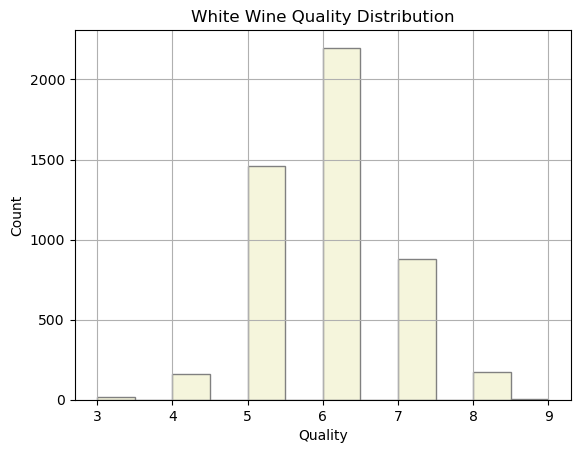

In [9]:
# Basic EDA (quick visuals)


def plot_quality_hist(df, title, color):
    plt.figure()
    df["quality"].hist(bins=12, color=color, edgecolor="gray")
    plt.title(title)
    plt.xlabel("Quality")
    plt.ylabel("Count")
    plt.show()

plot_quality_hist(red, "Red Wine Quality Distribution", "maroon")
plot_quality_hist(white, "White Wine Quality Distribution", "beige")

Most of the data falls between 3 and 8 on the quality scale, making really bad wines and really good wines rare.

<Axes: >

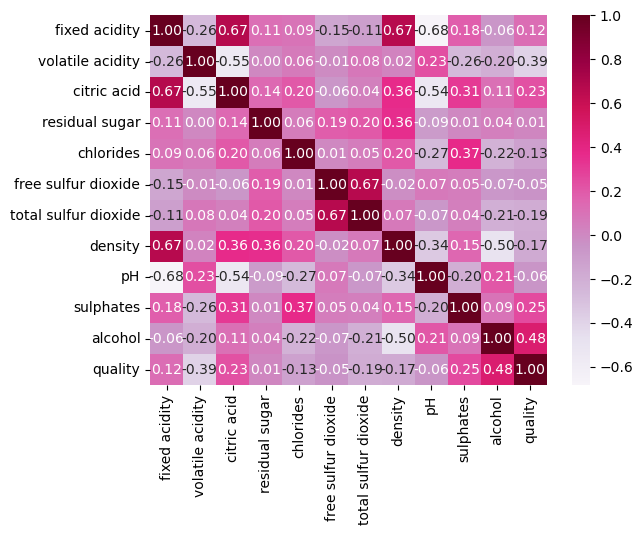

In [11]:
# correlation - red
sns.heatmap(red.corr(), annot=True, cmap="PuRd", fmt=".2f")

We see some moderate correlation between alcohol and quality, as well as sulphates and quality.

<Axes: >

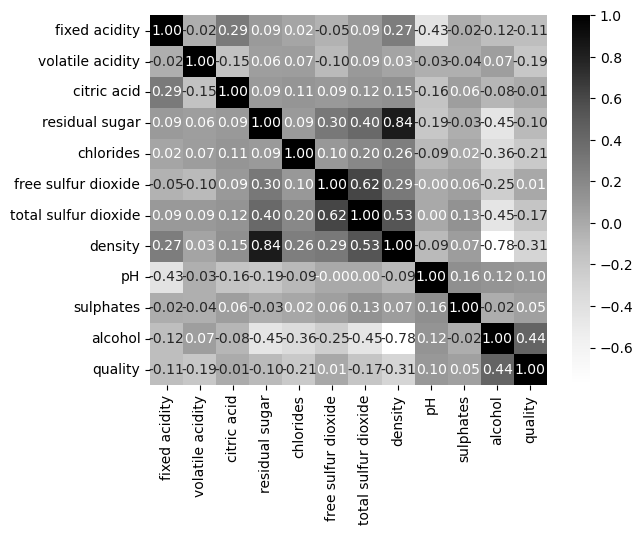

In [13]:
# correlation - white
sns.heatmap(white.corr(), annot=True, cmap="Greys", fmt=".2f")

We see some moderate correlation between alcohol and quality as well as density and quality.

In [15]:
# create function for scatterplot
def plot_feature_vs_quality(df, feature, title, color):
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df["quality"], color=color, edgecolor="gray", alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel("quality")
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

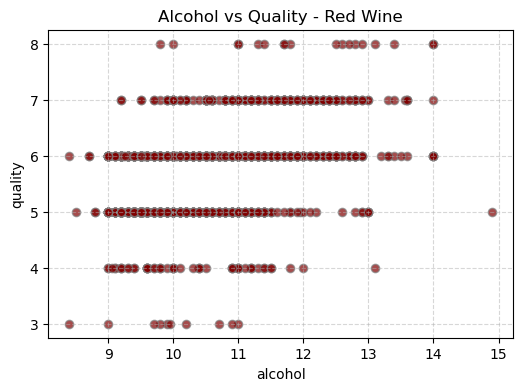

In [16]:
# alcohol vs quality red
plot_feature_vs_quality(red, "alcohol", "Alcohol vs Quality - Red Wine", "maroon")

There seems to be a distinct linear relationship between alcohol and quality.

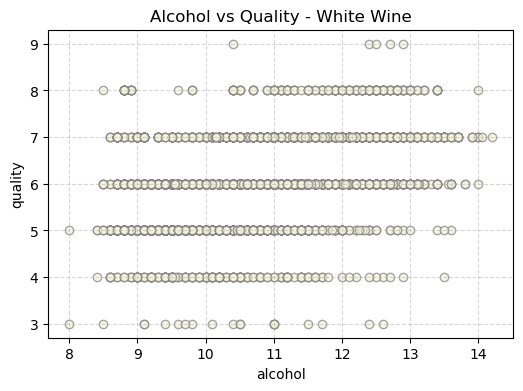

In [18]:
# alcohol vs quality white
plot_feature_vs_quality(white, "alcohol", "Alcohol vs Quality - White Wine", "beige")

There isn't as strong of a linear relationship between alcohol and quality compared to the red wines, but there still seems to be a relationship.

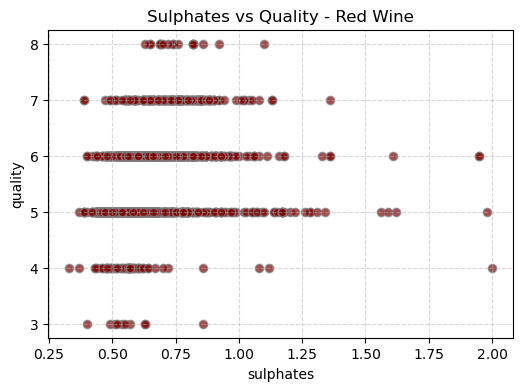

In [20]:
# sulphates vs quality red
plot_feature_vs_quality(red, "sulphates", "Sulphates vs Quality - Red Wine", "maroon")

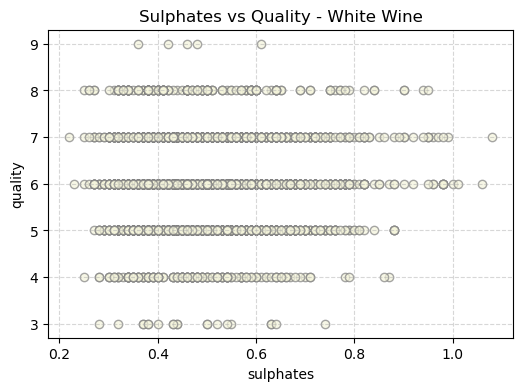

In [21]:
# sulphates vs quality white
plot_feature_vs_quality(white, "sulphates", "Sulphates vs Quality - White Wine", "beige")

## Preprocessing

In [23]:
#Split Features for Red
X_red = red.drop("quality", axis=1)
y_red = red["quality"]

In [24]:
#Split Features for White
X_white = white.drop("quality", axis=1)
y_white = white["quality"]

In [25]:
#Train/Test Split

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_red, y_red, test_size=0.2, random_state=42)

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_white, y_white, test_size=0.2, random_state=42)

In [26]:
# Scaling the data because each feature has a different scale
# set up the scaler
scaler = StandardScaler()
scaler.fit(Xr_train)
scaler.fit(Xw_train)

# transform the data
Xr_train_scaled = scaler.transform(Xr_train)
Xw_train_scaled = scaler.transform(Xw_train)
Xr_test_scaled = scaler.transform(Xr_test)
Xw_test_scaled = scaler.transform(Xw_test)

## Model Testing

### Red Wine Models

In [29]:
# Red Wine Regressions:
# Gradient Boosting Regressor
# define model
r_gbrt = GradientBoostingRegressor(random_state=42)

# Define hyperparameter grid
param_grid_r_gbrt = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8, 1.0]
}
# GridSearch with 10-fold CV
grid_search_r_gbrt = GridSearchCV(
    estimator=r_gbrt,
    param_grid=param_grid_r_gbrt,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search_r_gbrt.fit(Xr_train_scaled, yr_train)

# Print best model and parameters
print("Best parameters:", grid_search_r_gbrt.best_params_)
print("Best CV MSE:", grid_search_r_gbrt.best_score_)

# Obtain the best estimator from GridSearchCV
best_r_gbrt = grid_search_r_gbrt.best_estimator_

Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV MSE: -0.3873726367361975


In [30]:
# Red Wine Regressions:
# Random Forest Regressor
# define model
r_forest = RandomForestRegressor(bootstrap=True, random_state=42)

# Define hyperparameter grid
param_grid_r_forest = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 8],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# GridSearch with 10-fold CV
grid_search_r_forest = GridSearchCV(
    estimator=r_forest,
    param_grid=param_grid_r_forest,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search_r_forest.fit(Xr_train_scaled, yr_train)

# Print best model and parameters
print("Best parameters:", grid_search_r_forest.best_params_)
print("Best CV MSE:", grid_search_r_forest.best_score_)

# Obtain the best estimator from GridSearchCV
best_r_forest = grid_search_r_forest.best_estimator_

Fitting 10 folds for each of 48 candidates, totalling 480 fits
Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Best CV MSE: -0.3798671199727043


In [31]:
# Red Wine Regressions:
# Bagging Regressor
# define model and regularize it to reduce overfitting
r_dtree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
r_bag = BaggingRegressor(estimator = r_dtree, random_state=42)

# Define hyperparameter grid
param_grid_r_bag = {
    'n_estimators': [100, 300],
    'max_samples': [0.6, 0.8],
    'max_features': [0.7, 1.0]
}

# GridSearch with 10-fold CV
grid_search_r_bag = GridSearchCV(
    estimator=r_bag,
    param_grid=param_grid_r_bag,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search_r_bag.fit(Xr_train_scaled, yr_train)

# Print best model and parameters
print("Best parameters:", grid_search_r_bag.best_params_)
print("Best CV MSE:", grid_search_r_bag.best_score_)

# Obtain the best estimator from GridSearchCV
best_r_bag = grid_search_r_bag.best_estimator_

Fitting 10 folds for each of 8 candidates, totalling 80 fits
Best parameters: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 300}
Best CV MSE: -0.40805890105505904


### White Wine Models

In [33]:
# White Wine Regressions:
# Gradient Boosting Regressor
# define model
w_gbrt = GradientBoostingRegressor(random_state=42)

# Define hyperparameter grid
param_grid_w_gbrt = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.7, 0.8, 1.0]
}

# GridSearch with 10-fold CV
grid_search_w_gbrt = GridSearchCV(
    estimator=w_gbrt,
    param_grid=param_grid_w_gbrt,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search_w_gbrt.fit(Xw_train_scaled, yw_train)

# Print best model and parameters
print("Best parameters:", grid_search_w_gbrt.best_params_)
print("Best CV MSE:", grid_search_w_gbrt.best_score_)

# Obtain the best estimator from GridSearchCV
best_w_gbrt = grid_search_w_gbrt.best_estimator_

Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best CV MSE: -0.4733788146948793


In [34]:
# White Wine Regressions:
# Random Forest Regressor
# define model
w_forest = RandomForestRegressor(bootstrap=True,random_state=42)

# Define hyperparameter grid
param_grid_w_forest = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 8],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# GridSearch with 10-fold CV
grid_search_w_forest = GridSearchCV(
    estimator=w_forest,
    param_grid=param_grid_w_forest,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search_w_forest.fit(Xw_train_scaled, yw_train)

# Print best model and parameters
print("Best parameters:", grid_search_w_forest.best_params_)
print("Best CV MSE:", grid_search_w_forest.best_score_)

# Obtain the best estimator from GridSearchCV
best_w_forest = grid_search_w_forest.best_estimator_

Fitting 10 folds for each of 48 candidates, totalling 480 fits
Best parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MSE: -0.4690884731979635


In [93]:
# White Wine Regressions:
# Bagging Regressor
# define model and regularize it to reduce overfitting
w_dtree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
w_bag = BaggingRegressor(estimator = w_dtree, random_state=42)

# Define hyperparameter grid
param_grid_w_bag = {
    'n_estimators': [100, 300],
    'max_samples': [0.6, 0.8],
    'max_features': [0.7, 1.0]
}

# GridSearch with 10-fold CV
grid_search_w_bag = GridSearchCV(
    estimator=w_bag,
    param_grid=param_grid_w_bag,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)

# Fit
grid_search_w_bag.fit(Xw_train_scaled, yw_train)

# Print best model and parameters
print("Best parameters:", grid_search_w_bag.best_params_)
print("Best CV MSE:", grid_search_w_bag.best_score_)

# Obtain the best estimator from GridSearchCV
best_w_bag = grid_search_w_bag.best_estimator_

Best parameters: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 300}
Best CV MSE: -0.5312672690626067


### Model Evaluation and Testing

### Red Wine Models

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
R2 on training set: 0.707
R2 on test set: 0.466
MSE on test set: 0.349
RMSE on test set: 0.591
MAE on test set: 0.469


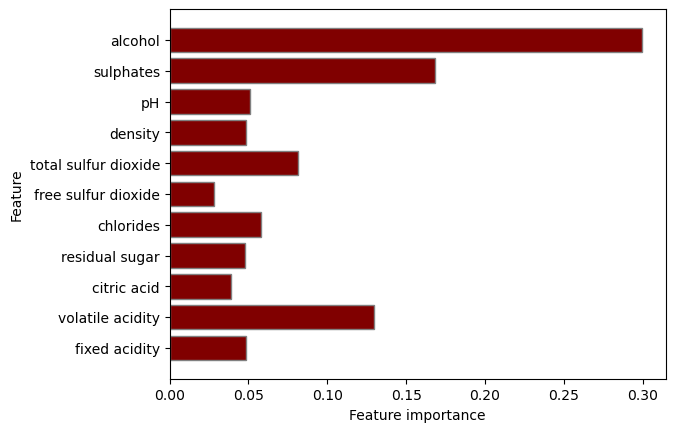

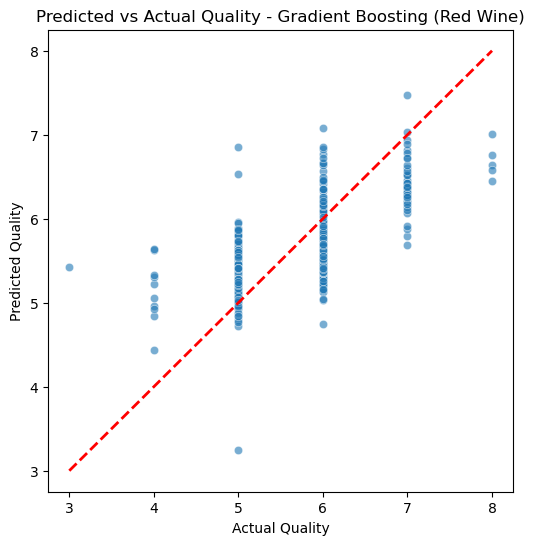

In [38]:
# Red Wine Models on test set
# Gradient Boosting

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_r_gbrt.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_r_gbrt.score(Xr_train_scaled, yr_train)))
print("R2 on test set: {:.3f}".format(best_r_gbrt.score(Xr_test_scaled, yr_test)))

# predict on test set
yr_pred_gbrt = best_r_gbrt.predict(Xr_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yr_test, yr_pred_gbrt)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yr_test, yr_pred_gbrt))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yr_test, yr_pred_gbrt)))

# determine what is the feature importance and interpret it
def plot_feature_importances_red(model):
    n_features = X_red.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center', color="maroon", edgecolor="gray")
    plt.yticks(np.arange(n_features), X_red.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)


plot_feature_importances_red(best_r_gbrt)
plt.show()

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yr_test, y=yr_pred_gbrt, alpha=0.6)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Gradient Boosting (Red Wine)")
plt.show()



Best hyperparameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
R2 on training set: 0.687
R2 on test set: 0.490
MSE on test set: 0.333
RMSE on test set: 0.577
MAE on test set: 0.465


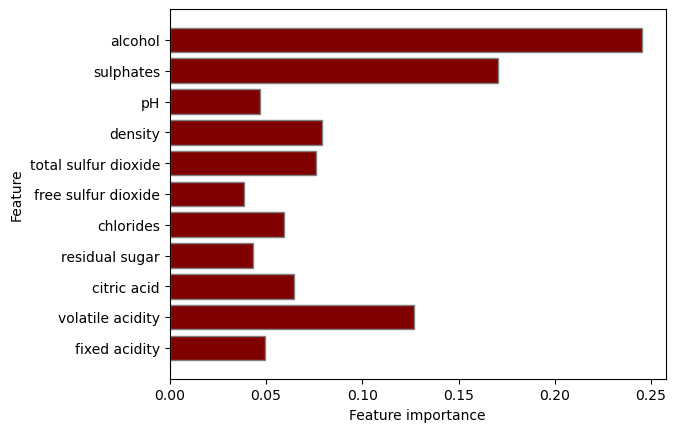

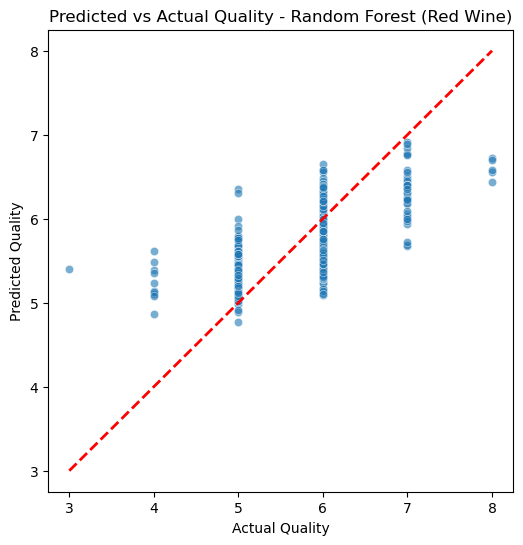

In [39]:
# Red Wine Models on test set
# Random Forest

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_r_forest.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_r_forest.score(Xr_train_scaled, yr_train)))
print("R2 on test set: {:.3f}".format(best_r_forest.score(Xr_test_scaled, yr_test)))

# predict on test set
yr_pred_rf = best_r_forest.predict(Xr_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yr_test, yr_pred_rf)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yr_test, yr_pred_rf))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yr_test, yr_pred_rf)))

# determine what is the feature importance and interpret it

plot_feature_importances_red(best_r_forest)
plt.show()

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yr_test, y=yr_pred_rf, alpha=0.6)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Random Forest (Red Wine)")
plt.show()

Random Forest produced the best evaluation metrics out of the three models, so we used that model for comparison graphs

Best hyperparameters: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 300}
R2 on training set: 0.465
R2 on test set: 0.417
MSE on test set: 0.381
RMSE on test set: 0.617
MAE on test set: 0.500


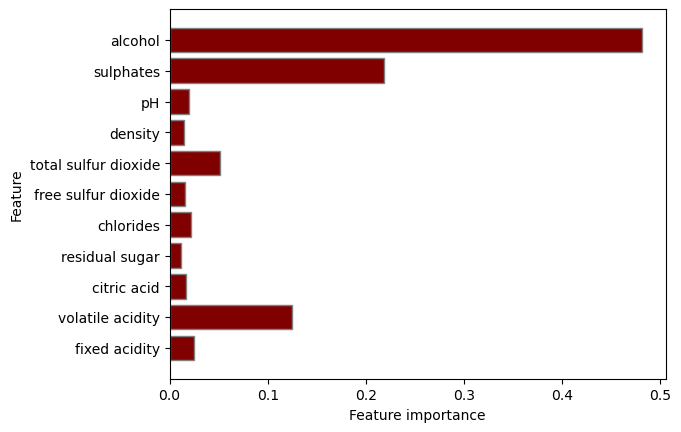

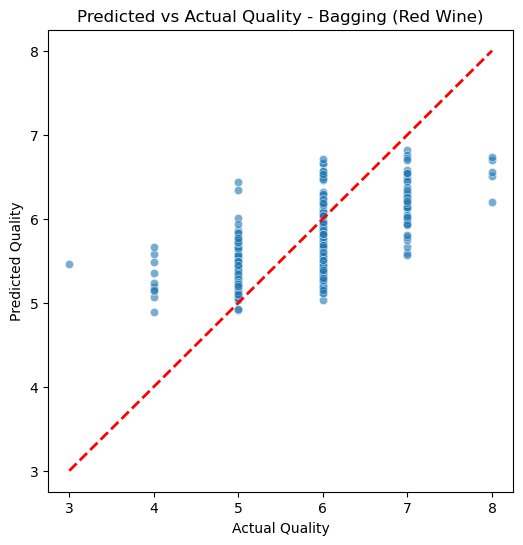

In [41]:
# Red Wine Models on test set
# Bagging

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_r_bag.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_r_bag.score(Xr_train_scaled, yr_train)))
print("R2 on test set: {:.3f}".format(best_r_bag.score(Xr_test_scaled, yr_test)))

# predict on test set
yr_pred_bag = best_r_bag.predict(Xr_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yr_test, yr_pred_bag)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yr_test, yr_pred_bag))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yr_test, yr_pred_bag)))

# determine what is the feature importance and interpret it
importances = np.mean([
    tree.feature_importances_ for tree in best_r_bag.estimators_
], axis=0)

def plot_feature_importances_red_bag(importances):
    n_features = X_red.shape[1]
    plt.barh(np.arange(n_features), importances, align='center', color="maroon", edgecolor="gray")
    plt.yticks(np.arange(n_features), X_red.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)


plot_feature_importances_red_bag(importances)
plt.show()

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yr_test, y=yr_pred_bag, alpha=0.6)
plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Bagging (Red Wine)")
plt.show()


### White Wine Models

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
R2 on training set: 0.544
R2 on test set: 0.426
MSE on test set: 0.444
RMSE on test set: 0.667
MAE on test set: 0.522


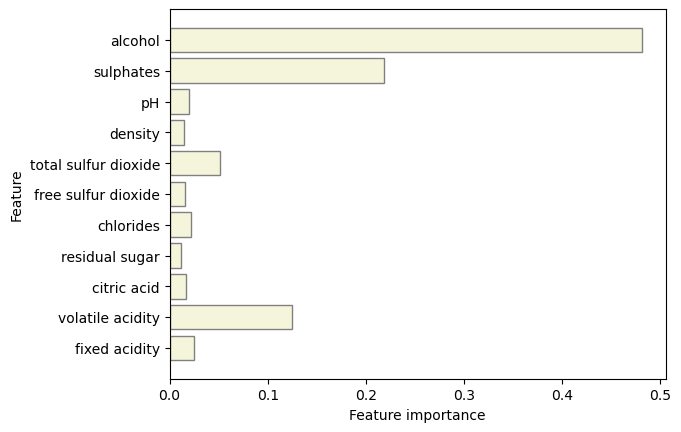

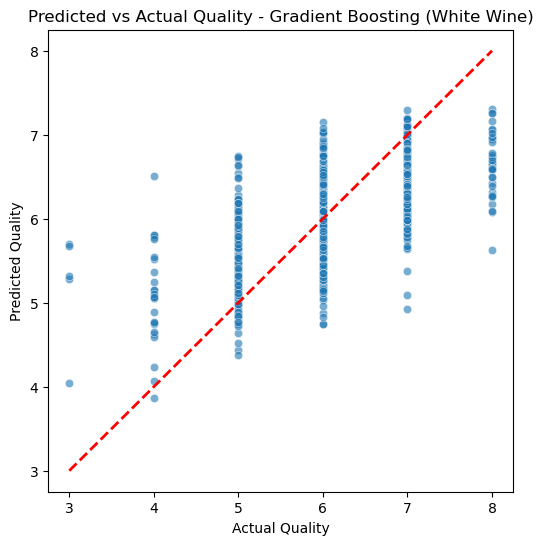

In [43]:
# White Wine Models on test set
# Gradient Boosting

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_w_gbrt.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_w_gbrt.score(Xw_train_scaled, yw_train)))
print("R2 on test set: {:.3f}".format(best_w_gbrt.score(Xw_test_scaled, yw_test)))

# predict on test set
yw_pred_gbrt = best_w_gbrt.predict(Xw_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yw_test, yw_pred_gbrt)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yw_test, yw_pred_gbrt))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yw_test, yw_pred_gbrt)))

# determine what is the feature importance and interpret it
def plot_feature_importances_white(model):
    n_features = X_white.shape[1]
    plt.barh(np.arange(n_features), importances, align='center', color="beige", edgecolor="gray")
    plt.yticks(np.arange(n_features), X_white.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_white(best_w_gbrt)
plt.show()

# determine what is the feature importance and interpret it

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yw_test, y=yw_pred_gbrt, alpha=0.6)
plt.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Gradient Boosting (White Wine)")
plt.show()

Best hyperparameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
R2 on training set: 0.559
R2 on test set: 0.424
MSE on test set: 0.446
RMSE on test set: 0.668
MAE on test set: 0.526


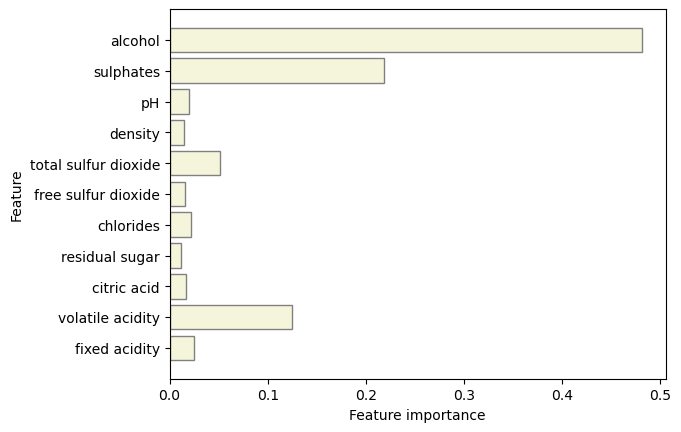

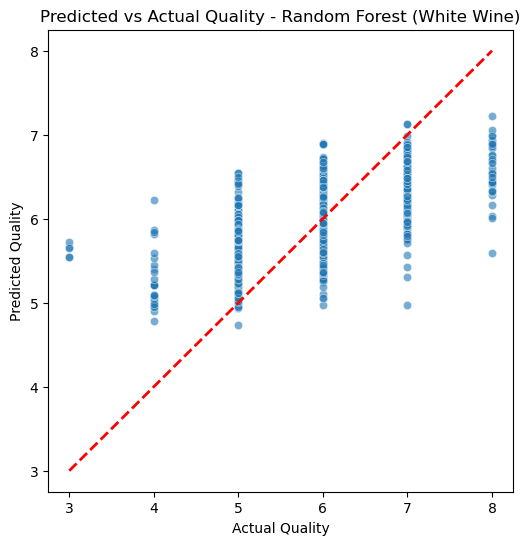

In [44]:
# White Wine Models on test set
# Random Forest

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_w_forest.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_w_forest.score(Xw_train_scaled, yw_train)))
print("R2 on test set: {:.3f}".format(best_w_forest.score(Xw_test_scaled, yw_test)))

# predict on test set
yw_pred_rf = best_w_forest.predict(Xw_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yw_test, yw_pred_rf)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yw_test, yw_pred_rf))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yw_test, yw_pred_rf)))

# determine what is the feature importance and interpret it
plot_feature_importances_white(best_w_forest)
plt.show()

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yw_test, y=yw_pred_rf, alpha=0.6)
plt.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Random Forest (White Wine)")
plt.show()

Random Forest produced the best *overall* evaluation metrics, so we used this model for comparison graphs

Best hyperparameters: {'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 300}
R2 on training set: 0.364
R2 on test set: 0.331
MSE on test set: 0.518
RMSE on test set: 0.720
MAE on test set: 0.572


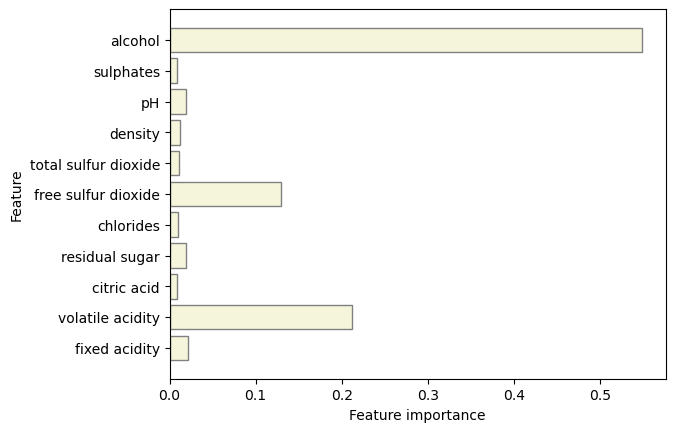

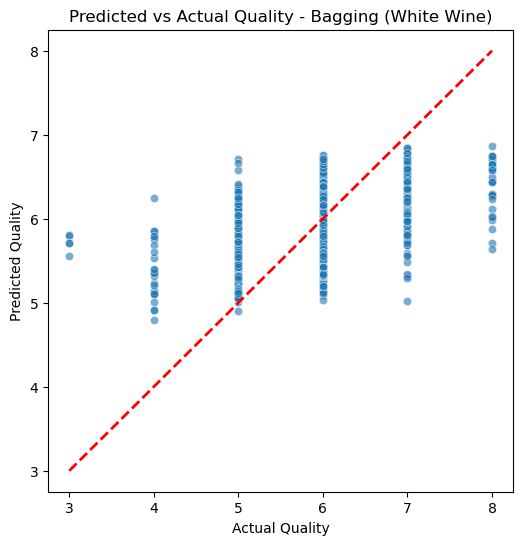

In [46]:
# White Wine Models on test set
# Bagging

# reiterate best hyperparameters
print("Best hyperparameters:", grid_search_w_bag.best_params_)

# Check the model performance
print("R2 on training set: {:.3f}".format(best_w_bag.score(Xw_train_scaled, yw_train)))
print("R2 on test set: {:.3f}".format(best_w_bag.score(Xw_test_scaled, yw_test)))

# predict on test set
yw_pred_bag = best_w_bag.predict(Xw_test_scaled)

# calculate error metrics
print("MSE on test set: {:.3f}".format(mean_squared_error(yw_test, yw_pred_bag)))
print("RMSE on test set: {:.3f}".format(np.sqrt(mean_squared_error(yw_test, yw_pred_bag))))
print("MAE on test set: {:.3f}".format(mean_absolute_error(yw_test, yw_pred_bag)))

# determine what is the feature importance and interpret it
importances = np.mean([
    tree.feature_importances_ for tree in best_w_bag.estimators_
], axis=0)

def plot_feature_importances_white_bag(importances):
    n_features = X_white.shape[1]
    plt.barh(np.arange(n_features), importances, align='center', color="beige", edgecolor="gray")
    plt.yticks(np.arange(n_features), X_white.columns)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_white_bag(importances)
plt.show()

# predicted vs actual plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=yw_test, y=yw_pred_bag, alpha=0.6)
plt.plot([yw_test.min(), yw_test.max()], [yw_test.min(), yw_test.max()], 'r--', lw=2)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Predicted vs Actual Quality - Bagging (White Wine)")
plt.show()

## Comparison of Datasets

In [48]:
def compare_feature_importances(model_red, model_white):
    
    features = X_red.columns
    n_features = len(features)
    
    red_importances = model_red.feature_importances_
    white_importances = model_white.feature_importances_
    
    y = np.arange(n_features)
    bar_width = 0.4

    plt.figure(figsize=(8,6))
    
    plt.barh(y - bar_width/2, red_importances, 
             height=bar_width, label="Red Wine Model", color="maroon", edgecolor="gray", linewidth=1)
    
    plt.barh(y + bar_width/2, white_importances, 
             height=bar_width, label="White Wine Model", color="beige", edgecolor="gray", linewidth=1)
    
    plt.yticks(y, features)
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance Comparison: Red vs White Wine")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

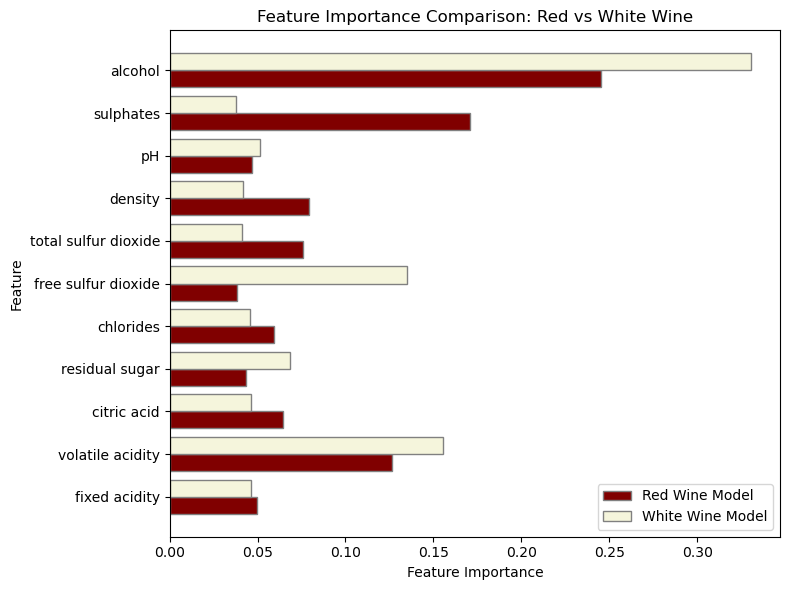

In [49]:
compare_feature_importances(best_r_forest, best_w_gbrt)

In [50]:
def plot_importance_difference(model_red, model_white):
    features = X_red.columns
    
    # define importances
    red_importances = model_red.feature_importances_
    white_importances = model_white.feature_importances_
    
    # normalize
    red_importances = red_importances / red_importances.sum()
    white_importances = white_importances / white_importances.sum()
    
    # calculate difference
    importance_diff = white_importances - red_importances
    
    # sort
    sorted_idx = np.argsort(importance_diff)
    
    features_sorted = features[sorted_idx]
    diff_sorted = importance_diff[sorted_idx]

    colors = ["beige" if val > 0 else "maroon" for val in diff_sorted]
    # create plot
    plt.figure(figsize=(8,6))
    plt.barh(features_sorted, diff_sorted, color=colors, edgecolor="gray")
    
    plt.axvline(0)
    plt.xlabel("Importance Difference (White − Red)")
    plt.ylabel("Feature")
    plt.title("Difference in Feature Importance Between Wine Models")

    
    plt.tight_layout()
    plt.show()

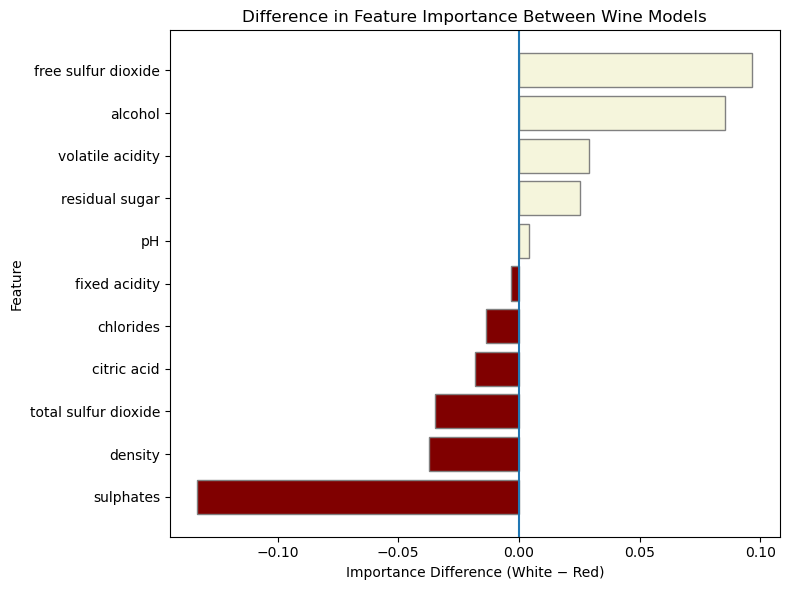

In [51]:
plot_importance_difference(best_r_forest, best_w_gbrt)

In [52]:
print("Red Wine")
print("Gradient Boosting:", mean_squared_error(yr_test, yr_pred_gbrt))
print("Random Forest:", mean_squared_error(yr_test, yr_pred_rf))
print("Bagging:", mean_squared_error(yr_test, yr_pred_bag))

print("\nWhite Wine")
print("Gradient Boosting:", mean_squared_error(yw_test, yw_pred_gbrt))
print("Random Forest:", mean_squared_error(yw_test, yw_pred_rf))
print("Bagging:", mean_squared_error(yw_test, yw_pred_bag))

Red Wine
Gradient Boosting: 0.349170641164786
Random Forest: 0.3332040849978425
Bagging: 0.38103305217121486

White Wine
Gradient Boosting: 0.4442524441408502
Random Forest: 0.44627328057928817
Bagging: 0.517917602202119


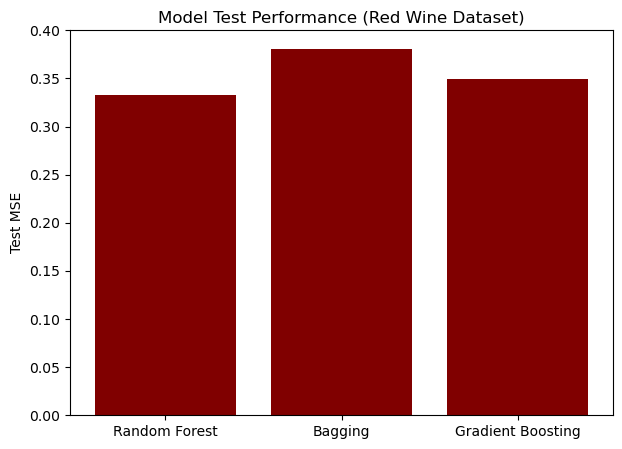

In [53]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Bagging", "Gradient Boosting"]
red_mse = [mean_squared_error(yr_test, yr_pred_rf), mean_squared_error(yr_test, yr_pred_bag), mean_squared_error(yr_test, yr_pred_gbrt)]

plt.figure(figsize=(7,5))
plt.bar(models, red_mse, color = "maroon")
plt.ylabel("Test MSE")
plt.title("Model Test Performance (Red Wine Dataset)")
plt.show()

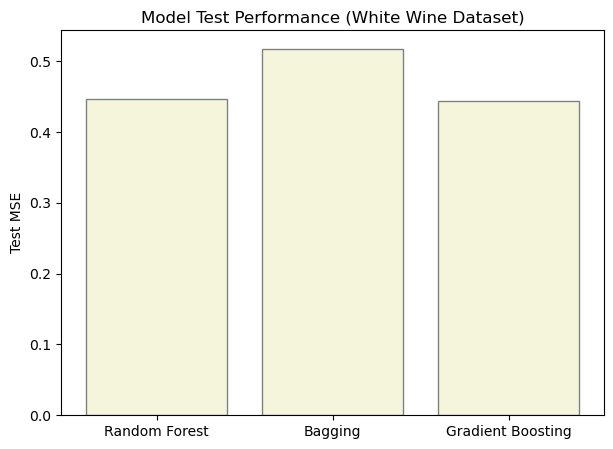

In [54]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Bagging", "Gradient Boosting"]
white_mse = [mean_squared_error(yw_test, yw_pred_rf), mean_squared_error(yw_test, yw_pred_bag), mean_squared_error(yw_test, yw_pred_gbrt)]

plt.figure(figsize=(7,5))
plt.bar(models, white_mse, color = "beige", edgecolor = "grey")

plt.ylabel("Test MSE")
plt.title("Model Test Performance (White Wine Dataset)")

plt.show()